In [1]:
import numpy as np
import time
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Đang tải dữ liệu đã tiền xử lý...")
# Tải file .npz đã lưu ở File 01
data = np.load('../data/processed/processed_data.npz')

# Trích xuất các biến
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

print("✅ Tải dữ liệu thành công!")
print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước y_train: {y_train.shape}")
print(f"Kích thước X_test: {X_test.shape}")
print(f"Kích thước y_test: {y_test.shape}")

Đang tải dữ liệu đã tiền xử lý...
✅ Tải dữ liệu thành công!
Kích thước X_train: (25157805, 18)
Kích thước y_train: (25157805,)
Kích thước X_test: (504473, 18)
Kích thước y_test: (504473,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC # Dùng LinearSVC thay vì SVC thường để chạy nhanh hơn trên dữ liệu lớn
from sklearn.ensemble import RandomForestClassifier

# Khởi tạo danh sách 5 mô hình
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "SVM (Linear)": LinearSVC(random_state=42, dual=False),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# Hàm dùng chung để huấn luyện, đánh giá và vẽ biểu đồ cho từng mô hình
def train_and_evaluate(model_name, model, X_train, y_train, X_test, y_test):
    print(f"\n{'='*50}")
    print(f"🚀 Đang huấn luyện mô hình: {model_name}...")
    
    # 1. Huấn luyện (Đo thời gian)
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    print(f"⏱️ Thời gian huấn luyện: {train_time:.2f} giây")
    
    # 2. Dự đoán
    print("🔍 Đang dự đoán trên tập Test...")
    y_pred = model.predict(X_test)
    
    # 3. Đánh giá
    acc = accuracy_score(y_test, y_pred)
    print(f"🎯 Độ chính xác (Accuracy): {acc:.4f}")
    
    print("\n📊 Báo cáo phân loại (Classification Report):")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # 4. Vẽ Confusion Matrix (Ma trận nhầm lẫn)
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Thực tế (True Label)')
    plt.xlabel('Dự đoán (Predicted Label)')
    plt.show()
    
    return model, acc

BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN...

🚀 Đang huấn luyện mô hình: Naive Bayes...
⏱️ Thời gian huấn luyện: 25.46 giây
🔍 Đang dự đoán trên tập Test...
🎯 Độ chính xác (Accuracy): 0.2530

📊 Báo cáo phân loại (Classification Report):
              precision    recall  f1-score   support

           0       1.00      0.21      0.35    419297
           1       0.00      0.77      0.01       391
           2       0.46      0.17      0.25     25603
           3       0.03      0.96      0.06      2057
           4       0.99      0.37      0.54     34570
           5       0.00      0.09      0.01      1046
           6       0.05      0.59      0.09      1077
           7       0.69      0.99      0.81      1187
           8       1.00      1.00      1.00         2
           9       0.00      0.86      0.00         7
          10       0.50      0.99      0.66     18164
          11       0.36      0.92      0.51       644
          12       0.00      0.00      0.00       294
          13       0

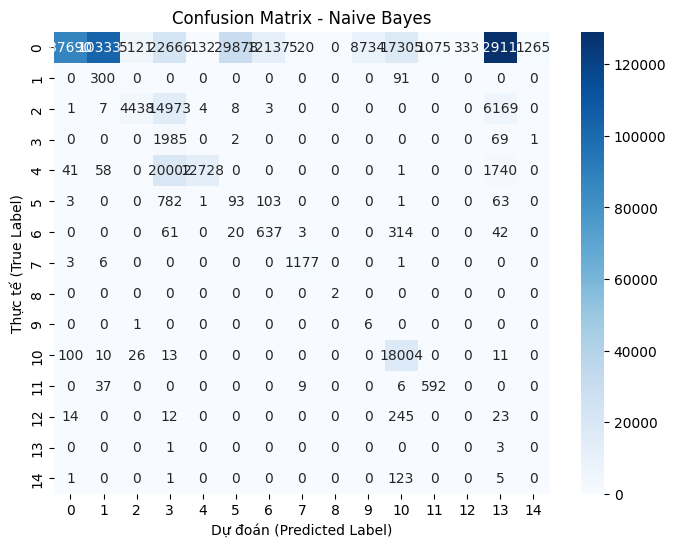


🚀 Đang huấn luyện mô hình: Logistic Regression...


d:\TaiLieu\Se_3_HK2\AT & BM HTTT\BT\Projects\Lab6.2_Network-Intrusion-Detection-ML\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [ ]:
# Tạo một từ điển để lưu các mô hình đã huấn luyện xong
trained_models = {}

# CHIẾN THUẬT: Chạy 3 mô hình này trước. 
# KNN và SVM tạm thời được comment lại (thêm dấu #) để tránh treo máy. 
# Bạn có thể mở comment chạy sau nếu máy có cấu hình thực sự mạnh (RAM > 16GB).
models_to_run = [
    "Naive Bayes", 
    "Logistic Regression", 
    "Random Forest" 
    # "KNN", 
    # "SVM (Linear)"
]

print("BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN...")
for name in models_to_run:
    try:
        model, acc = train_and_evaluate(name, models[name], X_train, y_train, X_test, y_test)
        trained_models[name] = model
    except Exception as e:
        print(f"❌ Lỗi khi chạy {name}: {e}")
        print("Có thể do máy tính bị thiếu RAM. Hãy thử khởi động lại Kernel và chỉ chạy duy nhất Random Forest.")

1. Đang lấy mẫu ngẫu nhiên 10% dữ liệu từ 25 triệu dòng gốc...
✅ Kích thước tập Train thu gọn: (2515780, 18)

2. BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN LẠI...

🚀 Đang huấn luyện mô hình: Naive Bayes...
⏱️ Thời gian huấn luyện: 1.28 giây
🔍 Đang dự đoán trên tập Test...
🎯 Độ chính xác (Accuracy): 0.2529

📊 Báo cáo phân loại (Classification Report):
              precision    recall  f1-score   support

           0       1.00      0.21      0.35    419297
           1       0.00      0.77      0.01       391
           2       0.46      0.17      0.25     25603
           3       0.03      0.96      0.06      2057
           4       0.99      0.37      0.54     34570
           5       0.00      0.09      0.01      1046
           6       0.05      0.59      0.09      1077
           7       0.69      0.99      0.81      1187
           8       1.00      1.00      1.00         2
           9       0.00      0.86      0.00         7
          10       0.50      0.99      0.66     18164
          11

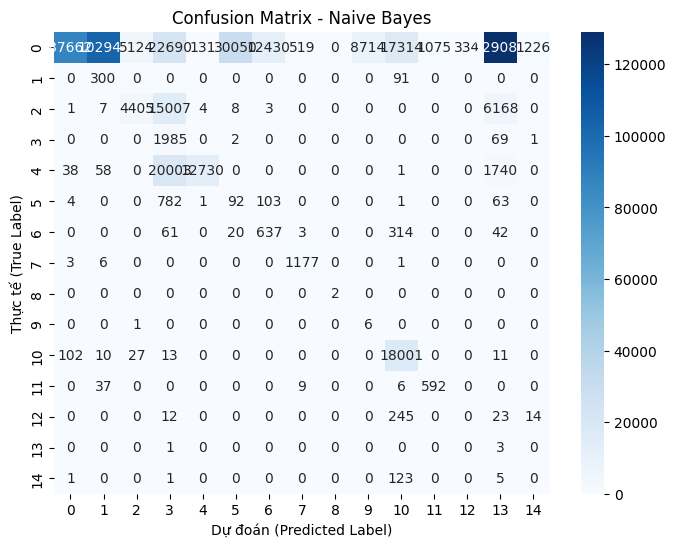


🚀 Đang huấn luyện mô hình: Logistic Regression...


d:\TaiLieu\Se_3_HK2\AT & BM HTTT\BT\Projects\Lab6.2_Network-Intrusion-Detection-ML\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


KeyboardInterrupt: 

In [3]:
from sklearn.utils import resample

print("1. Đang lấy mẫu ngẫu nhiên 10% dữ liệu từ 25 triệu dòng gốc...")
# Lấy ra 10% dữ liệu (khoảng 2.5 triệu dòng) và giữ nguyên tỷ lệ các loại tấn công (stratify)
X_train_sample, y_train_sample = resample(
    X_train, y_train, 
    n_samples=int(len(X_train) * 0.1), 
    random_state=42, 
    stratify=y_train
)

print(f"✅ Kích thước tập Train thu gọn: {X_train_sample.shape}")

print("\n2. BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN LẠI...")
trained_models = {}
models_to_run = ["Naive Bayes", "Logistic Regression", "Random Forest"]

for name in models_to_run:
    try:
        # LƯU Ý: Đưa X_train_sample vào thay vì X_train khổng lồ ban đầu
        model, acc = train_and_evaluate(name, models[name], X_train_sample, y_train_sample, X_test, y_test)
        trained_models[name] = model
    except Exception as e:
        print(f"❌ Lỗi khi chạy {name}: {e}")